In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import os
import math
import zipfile
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
import os
import glob
from skimage.metrics import structural_similarity as ssim

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
DATASET_PATH = "./CroppedYaleCopy/CroppedYale Project Data/CroppedYale" 

In [4]:
# Create the array of image vectors. 

dataset_path = DATASET_PATH

images = []

for subject in sorted(os.listdir(dataset_path)):
    
    subject_path = os.path.join(dataset_path, subject)
    
    if not os.path.isdir(subject_path):
        continue
        
    # Skip ambient images if any have been detected. 
    for file in os.listdir(subject_path):
        
        if "Ambient" in file:
            continue
            
        img_path = os.path.join(subject_path, file)
        
        img = Image.open(img_path).convert("L")
        img = np.array(img).astype("float32")
        
        images.append(img) # Append images

X = np.array(images)

print("Dataset shape:", X.shape)

Dataset shape: (2432, 192, 168)


In [5]:
X = np.array(images)

X = (X - X.min()) / (X.max() - X.min())

In [6]:
# Ensure reproducibility by setting the random seed to the same value as in the other experiments. 
np.random.seed(42)
torch.manual_seed(42)

images = []
masks = []
occluded_images = []
coords = []

for img in X:   # Loop over clean images in the dataset. 

    H, W = img.shape

    # Generate random mask size (same logic as U-Net):
    mask_h = np.random.randint(int(0.15 * H), int(0.30 * H))
    mask_w = np.random.randint(int(0.15 * W), int(0.30 * W))

    # Select random location: 
    x = np.random.randint(0, H - mask_h)
    y = np.random.randint(0, W - mask_w)

    mask = np.zeros_like(img)
    mask[x:x+mask_h, y:y+mask_w] = 1

    occluded = img.copy()
    occluded[mask == 1] = 0

    images.append(img)
    masks.append(mask)
    occluded_images.append(occluded)
    coords.append((x,y,mask_h,mask_w)) # Get the coordinates of the mask.

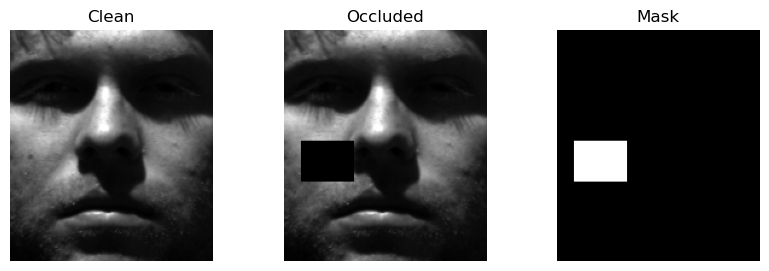

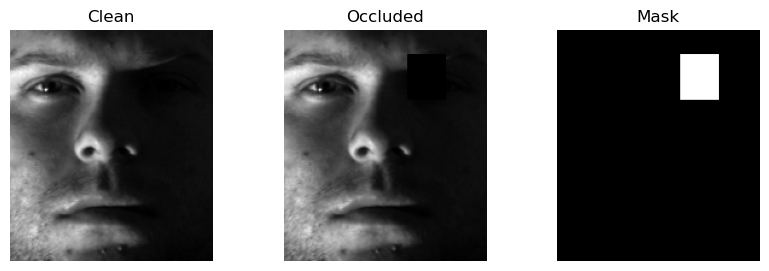

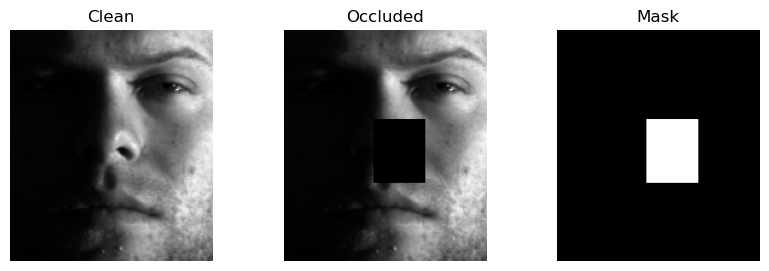

In [7]:
# Check if the occlusions were created successfully by printing out one set of clean, occluded and mask:
for i in range(3):

    clean = images[i]
    occ = occluded_images[i]
    mask = masks[i]

    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.title("Clean")
    plt.imshow(clean, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Occluded")
    plt.imshow(occ, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.show()

In [8]:
# Convert the arrays of images to tensors:
X_clean = torch.tensor(images, dtype=torch.float32).unsqueeze(1)
X_occluded = torch.tensor(occluded_images, dtype=torch.float32).unsqueeze(1)
X_masks = torch.tensor(masks, dtype=torch.float32).unsqueeze(1)

/tmp/ipykernel_578/3182951666.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  X_clean = torch.tensor(images, dtype=torch.float32).unsqueeze(1)


In [9]:
# Perform train-test split with the exact same parameters as in U-net. 
X_train_occ, X_test_occ, \
X_train_clean, X_test_clean, \
X_train_mask, X_test_mask = train_test_split(
    X_occluded,
    X_clean,
    X_masks,
    test_size=0.2,
    random_state=42
)

In [10]:
# Load the dataset using DataLoader:
train_dataset = TensorDataset(X_train_occ, X_train_clean, X_train_mask)
test_dataset = TensorDataset(X_test_occ, X_test_clean, X_test_mask)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [11]:
# This function converts a batch of images into patches. 
def patchify(imgs, patch_size):

    B, C, H, W = imgs.shape
    
    h = H // patch_size # Get the number of patches along the heigt of the image. 
    w = W // patch_size # Get the number of patches along the width of the image. 
    
    patches = imgs.reshape(B, C, h, patch_size, w, patch_size)
    patches = patches.permute(0,2,4,1,3,5)

    # Reshape the image into a grid of patches:
    patches = patches.reshape(B, h*w, C*patch_size*patch_size)
    
    return patches

In [12]:
# This image rconstructs an image from the predicted patches. 
def unpatchify(patches, patch_size, H, W):

    B, N, D = patches.shape
    
    C = 1 # Channel = 1 because the images are in grayscale. 
    h = H // patch_size # Get the number of patches along the height of the image.  
    w = W // patch_size # Get the number of patches along the width of the image.

    # Restore the grip of patches:
    patches = patches.reshape(B, h, w, C, patch_size, patch_size)
    patches = patches.permute(0,3,1,4,2,5)
    img = patches.reshape(B, C, H, W)
    
    return img

In [13]:
class MAETransformer(nn.Module):
    
    def __init__(self, patch_dim, embed_dim=256, num_heads=8, depth=6):
        
        super().__init__()
        
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )
        
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(embed_dim,256),
            nn.ReLU(),
            nn.Linear(256,patch_dim)
        )
        
    def forward(self,x):
        
        x = self.patch_embed(x)
        x = self.encoder(x)
        x = self.decoder(x)
        
        return x

In [14]:
patch_size = 8
patch_dim = 1 * patch_size * patch_size

model = MAETransformer(patch_dim).to(device)

# Set the optimizer as Adam:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Criterion for loss calculation is MSE:
criterion = nn.MSELoss()

In [15]:
epochs = 200

for epoch in range(epochs):

    total_loss = 0

    for occluded, target, mask in train_loader:

        # Move tensors to device: 
        occluded = occluded.to(device)
        target = target.to(device)    

        B,C,H,W = occluded.shape

        # Convert images into patches:
        occluded_patches = patchify(occluded, patch_size)
        target_patches = patchify(target, patch_size)

        # Convert masks into patches:
        mask_patches = patchify(mask, patch_size)
        mask_patches = mask_patches.to(device)
        
        # Forward pass of the occluded patches into the transformer:
        pred_patches = model(occluded_patches)

        # Calculate the loss on the masked pixels only in an attempt to 
        # making the model focus on reconstructing the missing region. 
        loss = ((pred_patches - target_patches) ** 2 * mask_patches).sum()

        # get avrage over the number of masked pixels: 
        loss = loss / mask_patches.sum()

        # Backpropogation:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))

Epoch 1 Loss: 0.04863811340793723
Epoch 2 Loss: 0.03915395668600915
Epoch 3 Loss: 0.03692485691338289
Epoch 4 Loss: 0.03470366684811526
Epoch 5 Loss: 0.03137054143962069
Epoch 6 Loss: 0.02761286818498715
Epoch 7 Loss: 0.025808823508683774
Epoch 8 Loss: 0.024092864390218356
Epoch 9 Loss: 0.02318542293410321
Epoch 10 Loss: 0.022102779487422744
Epoch 11 Loss: 0.021757880592199623
Epoch 12 Loss: 0.02077110851427815
Epoch 13 Loss: 0.02087020489280341
Epoch 14 Loss: 0.020804060439838738
Epoch 15 Loss: 0.01999185253392722
Epoch 16 Loss: 0.01985331530087307
Epoch 17 Loss: 0.0200295011115978
Epoch 18 Loss: 0.0194086905866556
Epoch 19 Loss: 0.01938107194088888
Epoch 20 Loss: 0.019161954012577285
Epoch 21 Loss: 0.01912378683518313
Epoch 22 Loss: 0.018812232971435687
Epoch 23 Loss: 0.018903660282614778
Epoch 24 Loss: 0.018209645494085845
Epoch 25 Loss: 0.01795194868273178
Epoch 26 Loss: 0.017690337049301532
Epoch 27 Loss: 0.017735102500186346
Epoch 28 Loss: 0.017619002724951895
Epoch 29 Loss: 0.01

In [16]:
# Here we perform reconstruction.
# Get one batch from the test set: 
occluded, target, mask = next(iter(test_loader))

# Move tensors to device: 
occluded = occluded.to(device)
target = target.to(device)
mask = mask.to(device)

B,C,H,W = occluded.shape

# Convert the occluded image to patches: 
occluded_patches = patchify(occluded, patch_size)

# Get the model prediction: 
pred_patches = model(occluded_patches)

# Convert the predicted patches back to an image: 
pred_img = unpatchify(pred_patches, patch_size, H, W)

# Combine preedicted masked regions with original visible pixels. 
#This is not including a bias since all our metrics throughout are being calculates ony over the masked region. 
recon = occluded*(1-mask) + pred_img*mask

In [17]:
# Here we calculate the metrics: 
recon_np = recon[0].detach().cpu().numpy().squeeze()
target_np = target[0].detach().cpu().numpy().squeeze()
mask_np = mask[0].detach().cpu().numpy().squeeze()

# Get only the masked pixels: 
masked_pixels = mask_np == 1

# Get the Mean Squared error over the masked region: 
mse = np.mean((recon_np[masked_pixels] - target_np[masked_pixels])**2)

# Get the Mean Absolute error over the masked region: 
mae = np.mean(np.abs(recon_np[masked_pixels] - target_np[masked_pixels]))

# Get the peak signal to noise ratio: (also for masked region only)
psnr = 10*np.log10(1/mse)

# Get SSIM - structural similarity index. 
# unlike the other metrics, SSIM is being caluclated for the entire image, not just the mask.
# This is because we are using SSIM as a measure for perceptual similiarty of the image as a whole
# to compare it to how humans would perceive the image. 
ssim_val = ssim(target_np, recon_np, data_range=1)

print("MSE:",mse)
print("MAE:",mae)
print("PSNR:",psnr)
print("SSIM:",ssim_val)

MSE: 0.00016791058
MAE: 0.011218926
PSNR: 37.74921945601034
SSIM: 0.9815001149543028


In [18]:
# This function helps us visualize some reconstructions: 
def show_reconstruction(index):

    occluded, target, mask = test_dataset[index]

    # add batch dimension
    occluded = occluded.unsqueeze(0).to(device)
    target = target.unsqueeze(0).to(device)
    mask = mask.unsqueeze(0).to(device)

    B,C,H,W = occluded.shape

    # convert to patches
    occluded_patches = patchify(occluded, patch_size)

    # predict patches
    pred_patches = model(occluded_patches)

    # reconstruct image
    pred_img = unpatchify(pred_patches, patch_size, H, W)

    recon = occluded*(1-mask) + pred_img*mask

    recon_np = recon[0].detach().cpu().numpy().squeeze()
    target_np = target[0].detach().cpu().numpy().squeeze()
    occluded_np = occluded[0].detach().cpu().numpy().squeeze()

    # visualization
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(target_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Masked")
    plt.imshow(occluded_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Reconstruction")
    plt.imshow(recon_np, cmap="gray")
    plt.axis("off")

    plt.show()

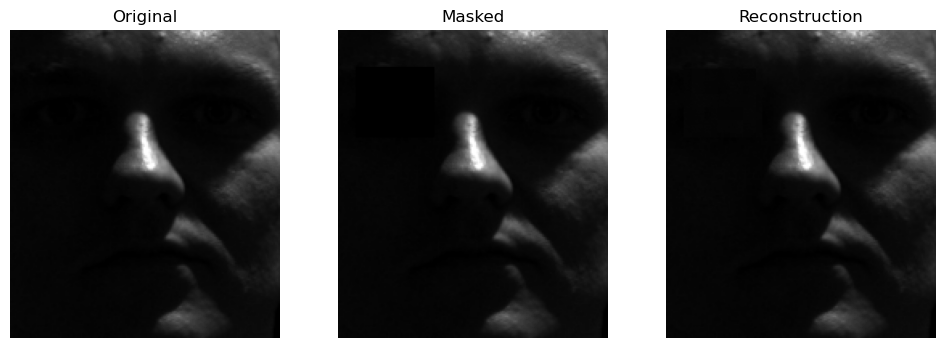

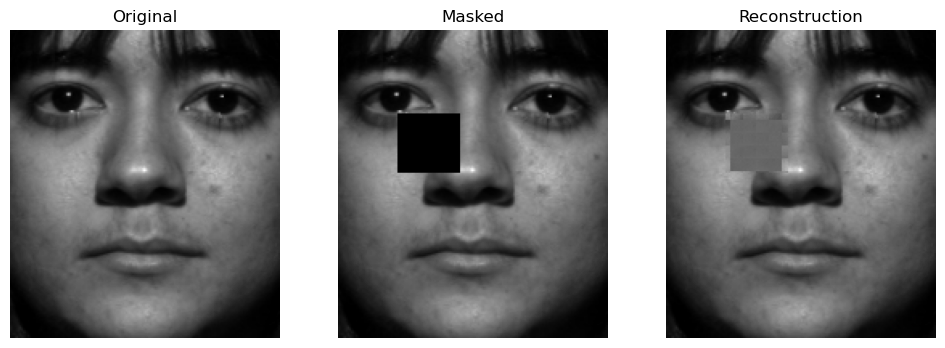

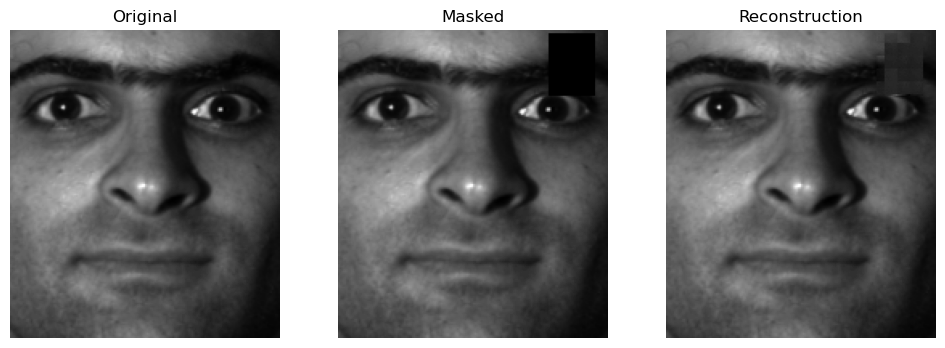

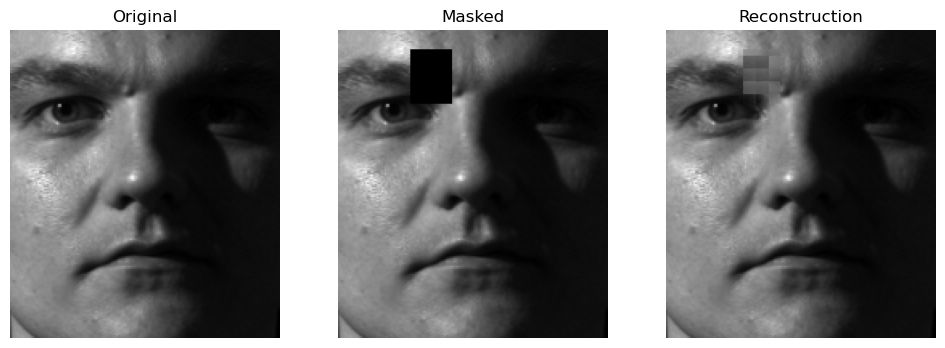

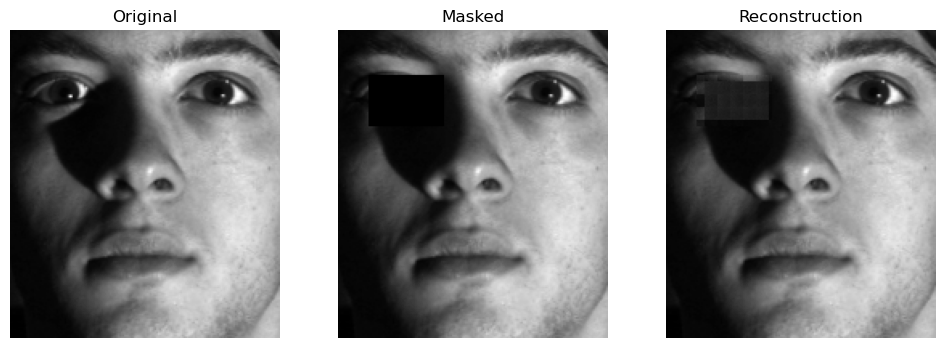

In [19]:
show_reconstruction(0)
show_reconstruction(5)
show_reconstruction(20)
show_reconstruction(50)
show_reconstruction(100)